# 01 — Shared Data Preparation

**Purpose.** Turn the teacher-provided metadata and images into one auditable,
leakage-safe data contract for all later notebooks.

**Scope.** This notebook audits files, reconciles IDs, checks image integrity,
finds duplicate/family relationships, verifies the protected split, prepares five
development folds, describes development labels, and publishes evidence.

**Out of scope.** It does not train a model, choose a metric, choose a final image
transform, fit model statistics, create a search index, or inspect holdout labels.

The narrative pattern is: **Purpose → Code → output below the code → Finding →
handoff file**. Small setup cells are explained briefly; complex audit cells show
their evidence path, row count, and SHA-256 where useful.


## 1. Runtime setup

**Purpose.** Resolve the repository without a machine-specific path, load only the
shared data API, and define small display/write helpers. The helpers do not make
modelling decisions.


In [1]:
from __future__ import annotations

import hashlib
import inspect
import json
import os
import subprocess
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageOps

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/fashion").is_dir():
            return candidate
    raise RuntimeError("Could not locate the project root")

ROOT = find_project_root(Path.cwd())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fashion.config import RANDOM_SEED, TARGET_COLUMNS
from fashion.data.audit import audit_image
from fashion.data.dataset import get_cv_split, iter_cv_folds, load_splits
from fashion.data.hashing import compute_sha256
from fashion.data.pipeline import prepare_data, validate_prepared_data_cache

TARGETS = tuple(TARGET_COLUMNS)
EVIDENCE_DIR = ROOT / "results/evidence/data_preparation"
FIGURE_DIR = ROOT / "results/figures/data_preparation"
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def relative(path: Path) -> str:
    return path.resolve().relative_to(ROOT).as_posix()

def sha256_file(path: Path) -> str:
    return compute_sha256(path)

def write_table(frame: pd.DataFrame, filename: str) -> str:
    path = EVIDENCE_DIR / filename
    frame.to_csv(path, index=False, lineterminator="\n")
    print(f"Wrote {relative(path)} | rows={len(frame):,} | sha256={sha256_file(path)}")
    return relative(path)

def save_figure(figure: plt.Figure, filename: str) -> dict[str, str]:
    path = FIGURE_DIR / filename
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return {"repository_path": relative(path), "sha256": sha256_file(path)}

pd.set_option("display.max_colwidth", 90)
print(f"Project root resolved: {ROOT.name}")
print(f"Seed: {RANDOM_SEED} | targets: {', '.join(TARGETS)}")


Project root resolved: MLA2
Seed: 2753 | targets: articleType, season, gender, usage


**Finding.** Paths are built from the repository root, so the notebook is portable.
The seed is shared only for reproducible auditing and examples.


## 2. Input/output map and run modes

**Purpose.** Make the data boundary visible before any analysis. Shared preparation
reads only `data/raw/teacher`. Its canonical outputs live in `data/processed`; report
evidence lives in `results/`.


In [2]:
source_map = pd.DataFrame(
    [
        ("labelled metadata", "data/raw/teacher/train/styles_train.csv", "read"),
        ("labelled images", "data/raw/teacher/train/images_train", "read"),
        ("official prediction template", "data/raw/teacher/test/styles_prediction.csv", "read IDs/header only"),
        ("official prediction images", "data/raw/teacher/test/images_test", "read"),
        ("canonical split and folds", "data/processed/splits.csv", "write/validate"),
        ("prediction manifest", "data/processed/prediction_manifest.csv", "write/validate"),
        ("audit tables", "data/processed/audit", "write/validate"),
        ("notebook evidence", "results/evidence/data_preparation", "write"),
        ("notebook figures", "results/figures/data_preparation", "write"),
    ],
    columns=["role", "repository_path", "access"],
)
source_map["exists_now"] = source_map["repository_path"].map(lambda value: (ROOT / value).exists())
display(source_map)


,role,repository_path,access,exists_now
0,labelled metadata,data/raw/teacher/train/styles_train.csv,read,True
1,labelled images,data/raw/teacher/train/images_train,read,True
2,official prediction template,data/raw/teacher/test/styles_prediction.csv,read IDs/header only,True
3,official prediction images,data/raw/teacher/test/images_test,read,True
4,canonical split and folds,data/processed/splits.csv,write/validate,True
5,prediction manifest,data/processed/prediction_manifest.csv,write/validate,True
6,audit tables,data/processed/audit,write/validate,True
7,notebook evidence,results/evidence/data_preparation,write,True
8,notebook figures,results/figures/data_preparation,write,True


**Finding.** The shared boundary is narrow and explicit. Later task notebooks receive
prepared manifests and must supply their own transforms.

Two modes are available:

- `cached` (default): validate teacher inputs and every critical prepared artifact.
- `full`: rebuild in a child process, then validate. The notebook kernel never holds
  protected target cells.


In [3]:
RUN_MODE = os.environ.get("FASHION_PREPARATION_MODE", "cached").strip().lower()
if RUN_MODE not in {"cached", "full"}:
    raise ValueError("FASHION_PREPARATION_MODE must be 'cached' or 'full'")

if RUN_MODE == "full":
    command = [
        sys.executable,
        "-c",
        "from fashion.data.pipeline import prepare_data; prepare_data()",
    ]
    subprocess.run(command, cwd=ROOT, check=True)

cache_status = validate_prepared_data_cache(ROOT)
display(pd.DataFrame([{ "run_mode": RUN_MODE, **cache_status }]))


,run_mode,cache,status,shared_source_policy,image_files_inventoried,image_files_content_sampled,protected_target_values_hashed
0,cached,data/processed/preparation_cache.json,validated,teacher_only,44442,128,0


**Finding.** The delivered cache is valid and teacher-only. Full mode is deliberately
isolated; cached mode makes repeated review fast without weakening the boundary.


## 3. Holdout boundary

**Purpose.** State the rule before loading the split. Notebook 01 may use all
`development` rows for descriptive EDA. It may use holdout/quarantine IDs and image
facts only for structural safety checks. Their target cells must remain blank.


In [4]:
splits = load_splits(ROOT / "data/processed/splits.csv")
protected = splits["partition"].isin(["holdout", "quarantine"])
boundary_checks = pd.DataFrame(
    [
        ("protected target cells are blank", all(splits.loc[protected, target].eq("").all() for target in TARGETS)),
        ("protected target masks are false", all((~splits.loc[protected, f"has_{target}_label"]).all() for target in TARGETS)),
        ("protected rows have no CV fold", splits.loc[protected, "cv_fold"].isna().all()),
        ("development rows have one CV fold", splits.loc[~protected & splits["partition"].eq("development"), "cv_fold"].between(0, 4).all()),
    ],
    columns=["boundary", "passed"],
)
display(boundary_checks)
assert boundary_checks["passed"].all()


,boundary,passed
0,protected target cells are blank,True
1,protected target masks are false,True
2,protected rows have no CV fold,True
3,development rows have one CV fold,True


**Finding.** The public manifest exposes structure but seals protected labels. The
holdout is not used for EDA, fitting, fold selection, or configuration changes.


## 4. Discover teacher sources

**Purpose.** Inventory the exact teacher files. For the official prediction CSV, the
public fingerprint uses only the header and ordered IDs; protected target cells are
excluded.


In [5]:
train_csv = ROOT / "data/raw/teacher/train/styles_train.csv"
prediction_csv = ROOT / "data/raw/teacher/test/styles_prediction.csv"
train_image_dir = ROOT / "data/raw/teacher/train/images_train"
prediction_image_dir = ROOT / "data/raw/teacher/test/images_test"

structural_summary_path = ROOT / "data/processed/audit/csv_summary.json"
structural_summary = json.loads(structural_summary_path.read_text(encoding="utf-8"))
fingerprint_key = {"train": "styles_train", "prediction": "styles_prediction"}
inventory_rows = []
for role, csv_path, image_dir in (
    ("train", train_csv, train_image_dir),
    ("prediction", prediction_csv, prediction_image_dir),
):
    ids = pd.read_csv(csv_path, usecols=["id"], keep_default_na=False)["id"]
    header = pd.read_csv(csv_path, nrows=0, keep_default_na=False).columns.tolist()
    files = sorted(path for path in image_dir.iterdir() if path.is_file())
    inventory_rows.append(
        {
            "role": role,
            "csv_path": relative(csv_path),
            "csv_rows": len(ids),
            "csv_unique_ids": ids.nunique(),
            "csv_duplicate_ids": ids.duplicated().sum(),
            "csv_columns": " | ".join(header),
            "public_header_and_ordered_id_sha256": structural_summary[fingerprint_key[role]]["header_and_id_sha256"],
            "protected_target_values_hashed": structural_summary[fingerprint_key[role]]["protected_target_values_hashed"],
            "image_dir": relative(image_dir),
            "image_files": len(files),
        }
    )
raw_inventory = pd.DataFrame(inventory_rows)
display(raw_inventory)
print(f"Read {relative(structural_summary_path)} | sha256={sha256_file(structural_summary_path)}")
write_table(raw_inventory, "raw_inventory.csv")


,role,csv_path,csv_rows,csv_unique_ids,csv_duplicate_ids,csv_columns,public_header_and_ordered_id_sha256,protected_target_values_hashed,image_dir,image_files
0,train,data/raw/teacher/train/styles_train.csv,38617,38617,0,id | gender | masterCategory | subCategory | articleType | baseColour | season | year ...,51d54a0bc077408b488cf006ec083f1c3569e7314a773ef9be72367c9cacdd87,0,data/raw/teacher/train/images_train,38613
1,prediction,data/raw/teacher/test/styles_prediction.csv,5829,5829,0,id | gender | articleType | season | usage,6de303f54b8c43737fe284e8c43db3151f0874f083c9280c73b114ff102c22ea,0,data/raw/teacher/test/images_test,5829


Read data/processed/audit/csv_summary.json | sha256=60d918b7812964b0b46fedc03f53186cbccb382427b37bdc0abedfca168fab49
Wrote results/evidence/data_preparation/raw_inventory.csv | rows=2 | sha256=af746f4fb92449c6219927bc124bfcf4dd34f9556369ff3c77596d535c0336ed


'results/evidence/data_preparation/raw_inventory.csv'

**Finding.** Each input is named and counted. Counting alone is not treated as proof;
exact ID reconciliation follows after byte hashing and decode verification.


## 5. Hash raw bytes before image decode

**Purpose.** Prove the required order: discover files → SHA-256 raw bytes → decode
and verify → reconcile exact IDs → analyse duplicates.


In [6]:
audit_source = inspect.getsource(audit_image)
sha_position = audit_source.index("compute_sha256(path)")
decode_position = audit_source.index("Image.open(path)")
stage_order = pd.DataFrame(
    [
        (1, "discover files", "directory inventory"),
        (2, "SHA-256 raw bytes", "compute_sha256(path)"),
        (3, "decode and verify", "Pillow verify/load"),
        (4, "exact ID reconciliation", "set comparison"),
        (5, "duplicate analysis", "exact and perceptual evidence"),
    ],
    columns=["order", "stage", "implementation_evidence"],
)
display(stage_order)
print(f"Source positions: SHA-256={sha_position}, first Image.open={decode_position}")
assert sha_position < decode_position
write_table(stage_order, "preparation_stage_order.csv")


,order,stage,implementation_evidence
0,1,discover files,directory inventory
1,2,SHA-256 raw bytes,compute_sha256(path)
2,3,decode and verify,Pillow verify/load
3,4,exact ID reconciliation,set comparison
4,5,duplicate analysis,exact and perceptual evidence


Source positions: SHA-256=801, first Image.open=835
Wrote results/evidence/data_preparation/preparation_stage_order.csv | rows=5 | sha256=de57780433a3d0ed1393188d85b396cb12ab7726eca7c7d34ef08745dba3978b


'results/evidence/data_preparation/preparation_stage_order.csv'

**Finding.** Source inspection confirms that the raw-byte digest is assigned before
Pillow opens the file. The written table fixes the five-stage audit order.


In [7]:
image_audit_path = ROOT / "data/processed/audit/image_audit.csv.gz"
image_audit = pd.read_csv(image_audit_path, keep_default_na=False)
image_audit["decode_ok_bool"] = image_audit["decode_ok"].astype(str).str.lower().eq("true")
raw_hashing_summary = (
    image_audit.groupby("role", dropna=False)
    .agg(
        discovered_files=("filename", "size"),
        raw_sha256_recorded=("sha256", lambda values: values.astype(str).str.len().eq(64).sum()),
        decode_ok=("decode_ok_bool", "sum"),
        decode_failed=("decode_ok_bool", lambda values: (~values).sum()),
    )
    .reset_index()
)
display(raw_hashing_summary)
print(f"Read {relative(image_audit_path)} | rows={len(image_audit):,} | sha256={sha256_file(image_audit_path)}")
write_table(raw_hashing_summary, "raw_hashing_summary.csv")


,role,discovered_files,raw_sha256_recorded,decode_ok,decode_failed
0,prediction,5829,5829,5829,0
1,train,38613,38612,38612,1


Read data/processed/audit/image_audit.csv.gz | rows=44,442 | sha256=e1255de28b73e5c71ca695db15071ee8cb8673c29d0a7c9782a1a0cce6ab8bc6
Wrote results/evidence/data_preparation/raw_hashing_summary.csv | rows=2 | sha256=bb17e8d7550b231e5f32b57fa81273f8623d4b7b3e420a752066ec4c3efe6e8a


'results/evidence/data_preparation/raw_hashing_summary.csv'

**Finding.** SHA-256 is computed before the first image decode call. This supports
exact-duplicate detection even when a decoder later rejects a file.


## 6. Image integrity and exact ID reconciliation

**Purpose.** Check duplicate CSV IDs, non-numeric stems, repeated numeric stems,
multiple extensions, missing/extra images, unsupported extensions, and corrupt files.
Official prediction IDs are a hard gate: any missing or corrupt item stops the run.


In [8]:
def reconciliation_for(role: str, csv_path: Path) -> list[dict[str, object]]:
    csv_ids = pd.read_csv(csv_path, usecols=["id"], keep_default_na=False)["id"].astype(int)
    files = image_audit[image_audit["role"].eq(role)].copy()
    files["numeric_id"] = pd.to_numeric(files["id"], errors="coerce")
    numeric = files[files["numeric_id"].notna()].copy()
    numeric["numeric_id"] = numeric["numeric_id"].astype(int)
    numeric["extension"] = numeric["filename"].map(lambda value: Path(str(value)).suffix.lower())
    valid_ids = set(numeric.loc[numeric["decode_ok_bool"], "numeric_id"])
    csv_id_set = set(csv_ids)
    multi_extension_ids = numeric.groupby("numeric_id")["extension"].nunique().gt(1)
    return [
        {"role": role, "check": "duplicate IDs in CSV", "count": int(csv_ids.duplicated().sum()), "details": ""},
        {"role": role, "check": "non-numeric filename stems", "count": int(files["numeric_id"].isna().sum()), "details": ""},
        {"role": role, "check": "numeric stems with multiple files", "count": int(numeric["numeric_id"].duplicated(keep=False).sum()), "details": ""},
        {"role": role, "check": "IDs with multiple extensions", "count": int(multi_extension_ids.sum()), "details": ""},
        {"role": role, "check": "metadata IDs without valid image", "count": len(csv_id_set - valid_ids), "details": ",".join(map(str, sorted(csv_id_set - valid_ids)))},
        {"role": role, "check": "extra valid image IDs", "count": len(valid_ids - csv_id_set), "details": ",".join(map(str, sorted(valid_ids - csv_id_set)))},
        {"role": role, "check": "unsupported extensions", "count": int(files["error"].eq("non_image_extension").sum()), "details": ""},
        {"role": role, "check": "corrupt supported images", "count": int((~files["decode_ok_bool"] & ~files["error"].eq("non_image_extension")).sum()), "details": ""},
    ]

reconciliation = pd.DataFrame(
    reconciliation_for("train", train_csv) + reconciliation_for("prediction", prediction_csv)
)
display(reconciliation)
write_table(reconciliation, "image_reconciliation.csv")

known_missing = {12347, 39401, 39403, 39410, 39425}
train_missing_text = reconciliation.loc[
    reconciliation["role"].eq("train")
    & reconciliation["check"].eq("metadata IDs without valid image"),
    "details",
].iloc[0]
observed_missing = {int(value) for value in train_missing_text.split(",") if value}
prediction_failures = reconciliation.loc[
    reconciliation["role"].eq("prediction")
    & reconciliation["check"].isin(["metadata IDs without valid image", "corrupt supported images"]),
    "count",
].sum()
assert observed_missing == known_missing
assert prediction_failures == 0, "Official prediction images are incomplete or corrupt"
print(f"Known teacher IDs without valid images: {sorted(observed_missing)}")
print("Official prediction image gate: PASSED")


,role,check,count,details
0,train,duplicate IDs in CSV,0,
1,train,non-numeric filename stems,1,
2,train,numeric stems with multiple files,0,
3,train,IDs with multiple extensions,0,
4,train,metadata IDs without valid image,5,"12347,39401,39403,39410,39425"
5,train,extra valid image IDs,0,
6,train,unsupported extensions,1,
7,train,corrupt supported images,0,
8,prediction,duplicate IDs in CSV,0,
9,prediction,non-numeric filename stems,0,


Wrote results/evidence/data_preparation/image_reconciliation.csv | rows=16 | sha256=2fcfeb0a2d2821d580e8e2471fc2ee0aae260f89a0d5b141fcdaee783bf3a294
Known teacher IDs without valid images: [12347, 39401, 39403, 39410, 39425]
Official prediction image gate: PASSED


**Finding.** Exactly five labelled metadata IDs have no valid image and are excluded
before splitting. Every official prediction ID has a valid image. The evidence uses
exact sets, not just matching totals.


## 7. Exact duplicates, perceptual candidates, families, and quarantine

**Purpose.** Inspect relationships that can leak near-identical products across
partitions or folds. Quarantine keeps unsafe rows visible but unusable.


In [9]:
exact_groups = pd.read_csv(ROOT / "data/processed/audit/exact_duplicate_groups.csv", keep_default_na=False)
near_candidates = pd.read_csv(ROOT / "data/processed/audit/near_duplicate_candidates.csv.gz", keep_default_na=False)
family_summary = json.loads((ROOT / "data/processed/audit/product_family_summary.json").read_text(encoding="utf-8"))
quarantine_counts = (
    splits.loc[splits["partition"].eq("quarantine"), "quarantine_reason"]
    .replace("", "unspecified")
    .value_counts()
)
duplicate_family_summary = pd.DataFrame(
    [
        ("exact duplicate groups", len(exact_groups)),
        ("exact groups crossing teacher roles", int(exact_groups["is_cross_role"].astype(str).str.lower().eq("true").sum())),
        ("perceptual candidate pairs", len(near_candidates)),
        ("accepted perceptual pairs", int(near_candidates["accepted_near_duplicate"].astype(str).str.lower().eq("true").sum())),
        ("active family groups", int(splits.loc[~splits["partition"].eq("quarantine"), "product_family_group"].nunique())),
        ("quarantined products", int(splits["partition"].eq("quarantine").sum())),
    ],
    columns=["fact", "count"],
)
display(duplicate_family_summary)
display(quarantine_counts.rename_axis("quarantine_reason").reset_index(name="products"))
write_table(duplicate_family_summary, "duplicate_family_summary.csv")


,fact,count
0,exact duplicate groups,652
1,exact groups crossing teacher roles,11
2,perceptual candidate pairs,113593
3,accepted perceptual pairs,2080
4,active family groups,27009
5,quarantined products,61


,quarantine_reason,products
0,conflicting_labels_exact_sha,41
1,cross_role_exact_duplicate,11
2,cross_role_near_duplicate_conservative_quarantine,9


Wrote results/evidence/data_preparation/duplicate_family_summary.csv | rows=6 | sha256=ab0524ca423a8e1e68797fe7e0913a1ca4f964a9a06e8390ee672bd23709257f


'results/evidence/data_preparation/duplicate_family_summary.csv'

**Finding.** The audit distinguishes exact matches, reviewed perceptual candidates,
connected product families, and rows excluded for a named quarantine reason.


In [10]:
def group_crossings(frame: pd.DataFrame, group_column: str) -> tuple[int, int, int]:
    usable = frame[frame[group_column].astype(str).ne("")].copy()
    active = usable[~usable["partition"].eq("quarantine")]
    active_partition_crossings = active.groupby(group_column)["partition"].nunique().gt(1).sum()
    development = usable[usable["partition"].eq("development")]
    fold_crossings = development.groupby(group_column)["cv_fold"].nunique().gt(1).sum()
    group_partitions = usable.groupby(group_column)["partition"].agg(set)
    quarantine_links = group_partitions.map(
        lambda values: "quarantine" in values and len(values - {"quarantine"}) > 0
    ).sum()
    return int(active_partition_crossings), int(fold_crossings), int(quarantine_links)

boundary_rows = []
for relationship in ("sha256", "duplicate_group", "product_family_group", "product_name_key"):
    partition_crossings, fold_crossings, quarantine_links = group_crossings(splits, relationship)
    boundary_rows.append((relationship, "group", partition_crossings, fold_crossings, quarantine_links))

accepted = near_candidates[
    near_candidates["accepted_near_duplicate"].astype(str).str.lower().eq("true")
][["id_1", "id_2"]].copy()
allocation = splits.set_index("id")[["partition", "cv_fold"]]
near_partition_crossings = 0
near_fold_crossings = 0
near_quarantine_links = 0
for pair in accepted.itertuples(index=False):
    if pair.id_1 not in allocation.index or pair.id_2 not in allocation.index:
        continue
    left = allocation.loc[pair.id_1]
    right = allocation.loc[pair.id_2]
    touches_quarantine = "quarantine" in {left["partition"], right["partition"]}
    near_quarantine_links += int(touches_quarantine and left["partition"] != right["partition"])
    if not touches_quarantine:
        near_partition_crossings += int(left["partition"] != right["partition"])
    if left["partition"] == right["partition"] == "development":
        near_fold_crossings += int(left["cv_fold"] != right["cv_fold"])
boundary_rows.append(
    ("accepted_perceptual_pair", "pair", near_partition_crossings, near_fold_crossings, near_quarantine_links)
)

accepted_cross_role = near_candidates[
    near_candidates["accepted_near_duplicate"].astype(str).str.lower().eq("true")
    & near_candidates["cross_role"].astype(str).str.lower().eq("true")
]
labelled_cross_role_ids = set(
    accepted_cross_role.loc[accepted_cross_role["role_1"].eq("labelled"), "id_1"].astype(int)
) | set(
    accepted_cross_role.loc[accepted_cross_role["role_2"].eq("labelled"), "id_2"].astype(int)
)
cross_role_component = (
    splits["is_cross_role_exact_duplicate"] | splits["is_cross_role_near_duplicate"]
)
cross_role_component_ids = set(splits.loc[cross_role_component, "id"].astype(int))
transitive_cross_role_ids = cross_role_component_ids - labelled_cross_role_ids
cross_role_component_not_quarantined = int(
    (~splits.loc[cross_role_component, "partition"].eq("quarantine")).sum()
)

group_boundary_audit = pd.DataFrame(
    boundary_rows,
    columns=[
        "relationship",
        "quarantine_relationship_unit",
        "active_partition_crossings",
        "development_fold_crossings",
        "relationships_to_quarantine",
    ],
)
display(group_boundary_audit)
assert group_boundary_audit[["active_partition_crossings", "development_fold_crossings"]].to_numpy().sum() == 0
write_table(group_boundary_audit, "group_boundary_audit.csv")

perceptual_scope_audit = pd.DataFrame(
    [
        ("accepted candidate pairs", len(accepted)),
        ("accepted pairs linking active data to quarantine", near_quarantine_links),
        ("direct cross-role labelled endpoints", len(labelled_cross_role_ids)),
        ("full cross-role component labelled products", len(cross_role_component_ids)),
        ("transitive cross-role component products", len(transitive_cross_role_ids)),
        ("cross-role component products outside quarantine", cross_role_component_not_quarantined),
    ],
    columns=["fact", "count"],
)
display(perceptual_scope_audit)
assert cross_role_component_not_quarantined == 0
write_table(perceptual_scope_audit, "perceptual_scope_audit.csv")


,relationship,quarantine_relationship_unit,active_partition_crossings,development_fold_crossings,relationships_to_quarantine
0,sha256,group,0,0,0
1,duplicate_group,group,0,0,0
2,product_family_group,group,0,0,0
3,product_name_key,group,0,0,13
4,accepted_perceptual_pair,pair,0,0,6


Wrote results/evidence/data_preparation/group_boundary_audit.csv | rows=5 | sha256=5a4f2eaebead8643d75e99ee6d4fa45a31f24739960edf84233ac2e43cf5c613


,fact,count
0,accepted candidate pairs,2080
1,accepted pairs linking active data to quarantine,6
2,direct cross-role labelled endpoints,19
3,full cross-role component labelled products,20
4,transitive cross-role component products,1
5,cross-role component products outside quarantine,0


Wrote results/evidence/data_preparation/perceptual_scope_audit.csv | rows=6 | sha256=ea3c6ca25f1e7bfae66f9f2c4d2452778000c189debda83b73cb3ce48fbbe532


'results/evidence/data_preparation/perceptual_scope_audit.csv'

**Finding.** Exact hashes, accepted perceptual pairs, family groups, and normalized
product names do not cross the active development/holdout boundary or development
folds. Links to quarantine are reported separately because those rows are deliberately
excluded. Rare rows are retained unless a documented safety reason sends them there.


## 8. Development, internal holdout, quarantine, and five CV folds

**Purpose.** Verify the single split and explain the practical ratio. The old train
and validation IDs form `development`; the existing holdout and quarantine IDs are
unchanged.


In [11]:
EXPECTED_DIGESTS = {
    "development": "2639d731f89942fd9598f9552bb092dd634830c3e6a63d0b569cfc2aa4362d01",
    "holdout": "48a9e2e389657744d2771a3ab5ca34e85e015b21b18ef4d0ed29c2e648cf8fc0",
    "quarantine": "5a672e34e485c8ddad0cef37c2dc37d99f8774f8874279a5d0ed69aff7022f43",
}

def id_set_digest(values: pd.Series) -> str:
    payload = "".join(f"{value}\n" for value in sorted(values.astype(int).tolist()))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

partition_summary = (
    splits["partition"].value_counts().rename_axis("partition").reset_index(name="products")
)
partition_summary["percent_of_image_backed"] = partition_summary["products"] / len(splits) * 100
partition_summary["id_set_sha256"] = partition_summary["partition"].map(
    lambda partition: id_set_digest(splits.loc[splits["partition"].eq(partition), "id"])
)
display(partition_summary)
assert dict(zip(partition_summary["partition"], partition_summary["id_set_sha256"])) == EXPECTED_DIGESTS
write_table(partition_summary, "partition_summary.csv")


,partition,products,percent_of_image_backed,id_set_sha256
0,development,32773,84.877758,2639d731f89942fd9598f9552bb092dd634830c3e6a63d0b569cfc2aa4362d01
1,holdout,5778,14.964260,48a9e2e389657744d2771a3ab5ca34e85e015b21b18ef4d0ed29c2e648cf8fc0
2,quarantine,61,0.157982,5a672e34e485c8ddad0cef37c2dc37d99f8774f8874279a5d0ed69aff7022f43


Wrote results/evidence/data_preparation/partition_summary.csv | rows=3 | sha256=86006f4bd3c047af2f3c1947bcaa643f5af93919245b38ce03d75f941f1d3199


'results/evidence/data_preparation/partition_summary.csv'

**Finding.** Membership counts and all three sorted-ID digests match the frozen
contract. This proves the old holdout and quarantine IDs were not re-sampled.


In [12]:
cv_rows = []
for fold, training, validation in iter_cv_folds(splits):
    cv_rows.append(
        {
            "validation_fold": fold,
            "training_products": len(training),
            "validation_products": len(validation),
            "holdout_products": int(splits["partition"].eq("holdout").sum()),
            "training_percent_all_image_backed": len(training) / len(splits) * 100,
            "validation_percent_all_image_backed": len(validation) / len(splits) * 100,
            "holdout_percent_all_image_backed": splits["partition"].eq("holdout").mean() * 100,
            "training_families": training["product_family_group"].nunique(),
            "validation_families": validation["product_family_group"].nunique(),
        }
    )
cv_balance = pd.DataFrame(cv_rows)
display(cv_balance.round(2))
development_for_cv = splits[splits["partition"].eq("development")]
fold_sizes = development_for_cv["cv_fold"].value_counts().sort_index()
largest_development_family = int(
    development_for_cv.groupby("product_family_group").size().max()
)
fold_size_range = int(fold_sizes.max() - fold_sizes.min())
print(
    f"Fold size range={fold_size_range}; largest development family={largest_development_family}"
)
assert fold_size_range <= largest_development_family
write_table(cv_balance, "cv_fold_balance.csv")


,validation_fold,training_products,validation_products,holdout_products,training_percent_all_image_backed,validation_percent_all_image_backed,holdout_percent_all_image_backed,training_families,validation_families
0,0,26218,6555,5778,67.90,16.98,14.96,18334,4565
1,1,26218,6555,5778,67.90,16.98,14.96,18314,4585
2,2,26219,6554,5778,67.90,16.97,14.96,18303,4596
3,3,26217,6556,5778,67.90,16.98,14.96,18346,4553
4,4,26220,6553,5778,67.91,16.97,14.96,18299,4600


Fold size range=3; largest development family=80
Wrote results/evidence/data_preparation/cv_fold_balance.csv | rows=5 | sha256=4c8a6d22324c13225b09252dfb5914f9eeab87720eee7c8914d5ced6f9ed36b2


'results/evidence/data_preparation/cv_fold_balance.csv'

**Finding.** One CV round is about 68% train, 17% validation, and 15% untouched
holdout. Family grouping makes counts close to—not exactly—the ideal. A task owner
must choose either one fixed validation fold or all five folds before experiments;
selecting the best-looking fold is invalid.


## 9. Development-only target analysis

**Purpose.** Describe label availability and class shape using development only.
`development` includes the old train and validation rows. Holdout and quarantine
labels are absent from every calculation below.


In [13]:
development = splits[splits["partition"].eq("development")].copy()
target_rows = []
for target in TARGETS:
    valid = development[f"has_{target}_label"]
    counts = development.loc[valid, target].astype(str).value_counts()
    target_rows.append(
        {
            "target": target,
            "development_products": len(development),
            "labelled_products": int(valid.sum()),
            "missing_products": int((~valid).sum()),
            "classes": int(counts.size),
            "largest_class_products": int(counts.max()),
            "smallest_class_products": int(counts.min()),
            "largest_to_smallest_ratio": float(counts.max() / counts.min()),
        }
    )
target_summary = pd.DataFrame(target_rows)
display(target_summary.round(2))
write_table(target_summary, "target_summary.csv")
print(
    "Literal 'NA' usage rows with a true mask:",
    int((development["usage"].eq("NA") & development["has_usage_label"]).sum()),
)


,target,development_products,labelled_products,missing_products,classes,largest_class_products,smallest_class_products,largest_to_smallest_ratio
0,articleType,32773,32773,0,124,5748,1,5748.00
1,season,32773,32753,20,4,16235,1329,12.22
2,gender,32773,32773,0,5,17753,543,32.69
3,usage,32773,32772,1,9,25151,1,25151.00


Wrote results/evidence/data_preparation/target_summary.csv | rows=4 | sha256=32bb9d9caac86a939d5cd341135a087953f63fcef394c9deecd8b9203070e8cf
Literal 'NA' usage rows with a true mask: 61


**Finding.** The table separates genuinely blank labels from valid strings. Class
counts and imbalance ratios describe development only.


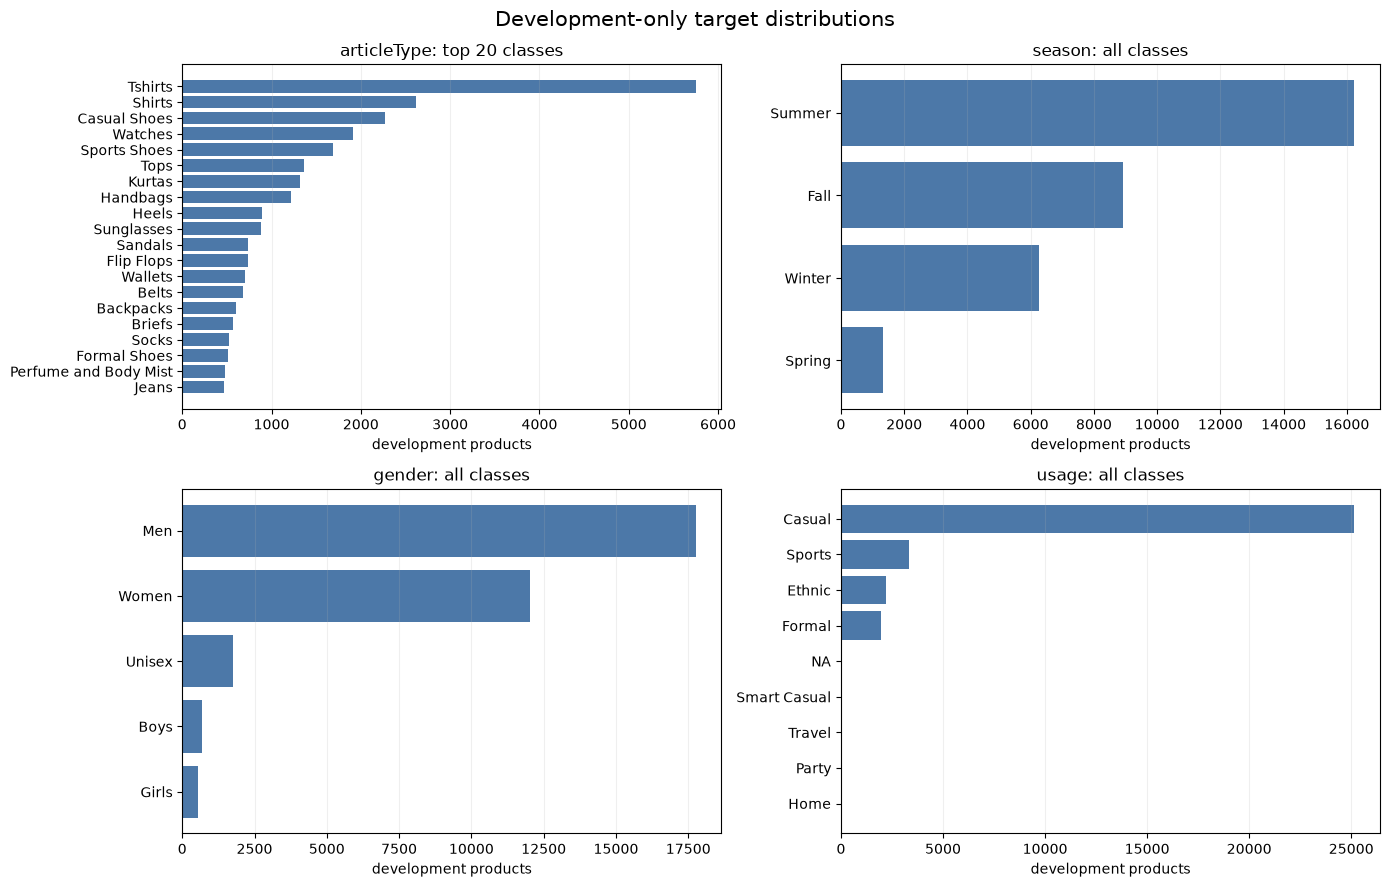

,repository_path,sha256
0,results/figures/data_preparation/target_distributions.png,7a08d09988dc626a0d16746bf450ded5066c469f154a1e2b5f2e12c5ebe43c33


In [14]:
figure, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, target in zip(axes.ravel(), TARGETS):
    valid = development[f"has_{target}_label"]
    counts = development.loc[valid, target].astype(str).value_counts()
    shown = counts.head(20 if target == "articleType" else len(counts)).sort_values()
    axis.barh(shown.index, shown.values, color="#4C78A8")
    axis.set_title(f"{target}: {'top 20 classes' if target == 'articleType' else 'all classes'}")
    axis.set_xlabel("development products")
    axis.grid(axis="x", alpha=0.2)
figure.suptitle("Development-only target distributions", fontsize=15)
figure.tight_layout()
figure_record = save_figure(figure, "target_distributions.png")
plt.show()
display(pd.DataFrame([figure_record]))


**Finding.** Label availability differs by target, and several targets have long
tails. Literal `NA` is a real teacher label; only truly blank cells are missing.
This is evidence for task owners, not a choice of loss, sampler, or metric.


## 10. Imbalance and class support by fold

**Purpose.** Show whether each development label is available in each fold and in
the corresponding four-fold training portion. No class is removed merely for being
rare.


In [15]:
class_summary_path = ROOT / "data/processed/development_class_summary.csv"
class_summary = pd.read_csv(class_summary_path, keep_default_na=False)
rare_classes = class_summary[
    class_summary["rare_warning"].astype(str).ne("")
    | pd.to_numeric(class_summary["untrainable_fold_count"], errors="coerce").gt(0)
].copy()
imbalance_handoff = (
    class_summary.groupby("target", as_index=False)
    .agg(
        classes=("class", "size"),
        classes_in_all_folds=("fold_count", lambda values: pd.to_numeric(values).eq(5).sum()),
        classes_with_warning=("rare_warning", lambda values: values.astype(str).ne("").sum()),
        classes_untrainable_in_any_fold=("untrainable_fold_count", lambda values: pd.to_numeric(values).gt(0).sum()),
        minimum_class_products=("development_product_count", lambda values: pd.to_numeric(values).min()),
    )
)
display(imbalance_handoff)
display(
    rare_classes[
        ["target", "class", "development_product_count", "development_family_count", "folds_present", "minimum_fold_training_products", "untrainable_fold_count", "rare_warning"]
    ].head(30)
)
print(f"Read {relative(class_summary_path)} | rows={len(class_summary):,} | sha256={sha256_file(class_summary_path)}")
write_table(imbalance_handoff, "imbalance_handoff.csv")


,target,classes,classes_in_all_folds,classes_with_warning,classes_untrainable_in_any_fold,minimum_class_products
0,articleType,124,98,26,12,1
1,gender,5,5,0,0,543
2,season,4,4,0,0,1329
3,usage,9,8,1,1,1


,target,class,development_product_count,development_family_count,folds_present,minimum_fold_training_products,untrainable_fold_count,rare_warning
1,articleType,Baby Dolls,2,2,"1,2",1,0,low_independent_family_support
7,articleType,Body Wash and Scrub,1,1,1,0,1,untrainable_in_one_or_more_folds
20,articleType,Compact,4,1,2,0,1,untrainable_in_one_or_more_folds
21,articleType,Concealer,2,1,4,0,1,untrainable_in_one_or_more_folds
23,articleType,Cushion Covers,1,1,1,0,1,untrainable_in_one_or_more_folds
29,articleType,Eyeshadow,4,3,"0,2,4",2,0,low_independent_family_support
39,articleType,Hat,2,2,"1,2",1,0,low_independent_family_support
42,articleType,Highlighter and Blush,4,1,3,0,1,untrainable_in_one_or_more_folds
44,articleType,Ipad,1,1,1,0,1,untrainable_in_one_or_more_folds
51,articleType,Key chain,1,1,2,0,1,untrainable_in_one_or_more_folds


Read data/processed/development_class_summary.csv | rows=142 | sha256=1be4769870d0650ea321af8b97f619dabfa04c46ce8b1fc825ed9e13a18312f8
Wrote results/evidence/data_preparation/imbalance_handoff.csv | rows=4 | sha256=480b00f4d2c8cd39d4a44241645d67ed00b52bde9bcb05f1b9193c444fc262b5


'results/evidence/data_preparation/imbalance_handoff.csv'

**Finding.** Some labels are too rare to appear in the training side of every fold.
Those rows and labels remain in the contract, with an explicit warning. Any learned
response to imbalance must be fitted again using only the training folds of that
experiment.


## 11. Association among categorical targets (NMI)

**Purpose.** Use normalized mutual information (NMI) to see how strongly pairs of
categorical targets co-vary in development. NMI is an association score, not proof
that one target causes another.


In [16]:
def normalized_mutual_information(left: pd.Series, right: pd.Series) -> float:
    table = pd.crosstab(left.astype(str), right.astype(str)).to_numpy(dtype=float)
    probability = table / table.sum()
    left_probability = probability.sum(axis=1, keepdims=True)
    right_probability = probability.sum(axis=0, keepdims=True)
    expected = left_probability @ right_probability
    positive = probability > 0
    mutual_information = np.sum(probability[positive] * np.log(probability[positive] / expected[positive]))
    left_entropy = -np.sum(left_probability[left_probability > 0] * np.log(left_probability[left_probability > 0]))
    right_entropy = -np.sum(right_probability[right_probability > 0] * np.log(right_probability[right_probability > 0]))
    denominator = (left_entropy + right_entropy) / 2
    return float(mutual_information / denominator) if denominator else 0.0

"definition-only: normalized_mutual_information for categorical development labels"


'definition-only: normalized_mutual_information for categorical development labels'

**Definition only.** The helper computes one symmetric categorical association score;
the next cell applies it and records sample sizes.


,articleType,season,gender,usage
articleType,1.000,0.174,0.194,0.254
season,0.174,1.000,0.024,0.038
gender,0.194,0.024,1.000,0.104
usage,0.254,0.038,0.104,1.000


,target_1,target_2,n,nmi
0,articleType,season,32753,0.174
1,articleType,gender,32773,0.194
2,articleType,usage,32772,0.254
3,season,gender,32753,0.024
4,season,usage,32752,0.038
5,gender,usage,32772,0.104


Wrote results/evidence/data_preparation/joint_target_nmi.csv | rows=6 | sha256=4187ef751040b3fa38ddf6f4cb6dd3425318a09ebe499d5e5c879a3e76cc2631


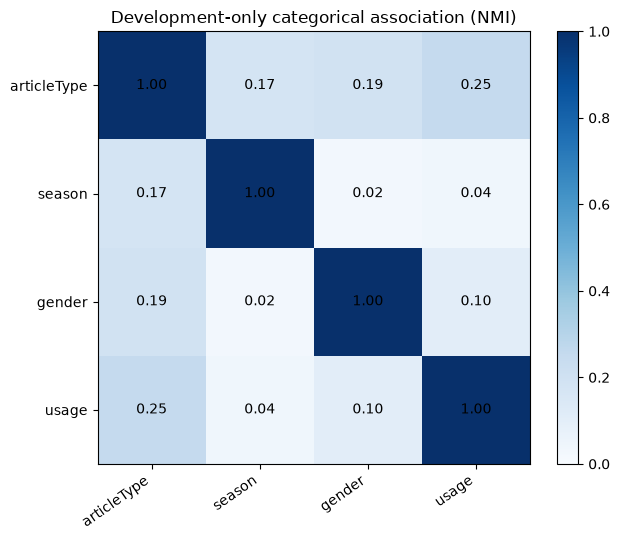

,repository_path,sha256
0,results/figures/data_preparation/joint_target_nmi.png,f840fca8fd5315bf8a34e35f1da2ca61d24d47f1e993ea0a68518e6360b21697


In [17]:
nmi = pd.DataFrame(np.eye(len(TARGETS)), index=TARGETS, columns=TARGETS, dtype=float)
nmi_sample_sizes = []
for left, right in combinations(TARGETS, 2):
    valid = development[f"has_{left}_label"] & development[f"has_{right}_label"]
    score = normalized_mutual_information(development.loc[valid, left], development.loc[valid, right])
    nmi.loc[left, right] = nmi.loc[right, left] = score
    nmi_sample_sizes.append({"target_1": left, "target_2": right, "n": int(valid.sum()), "nmi": score})
nmi_long = pd.DataFrame(nmi_sample_sizes)
display(nmi.round(3))
display(nmi_long.round(3))
write_table(nmi_long, "joint_target_nmi.csv")

figure, axis = plt.subplots(figsize=(6.5, 5.5))
image = axis.imshow(nmi.to_numpy(), vmin=0, vmax=1, cmap="Blues")
axis.set_xticks(range(len(TARGETS)), TARGETS, rotation=35, ha="right")
axis.set_yticks(range(len(TARGETS)), TARGETS)
for row in range(len(TARGETS)):
    for column in range(len(TARGETS)):
        axis.text(column, row, f"{nmi.iloc[row, column]:.2f}", ha="center", va="center")
axis.set_title("Development-only categorical association (NMI)")
figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
figure_record = save_figure(figure, "joint_target_nmi.png")
plt.show()
display(pd.DataFrame([figure_record]))


**Finding.** The targets are not independent, so later error analysis should check
joint slices. The table records the complete-case sample size for every pair and must
not be read as causality.


## 12. Development image profile and quality correlations

**Purpose.** Describe geometry and a fixed sample of simple visual properties. This
profile is diagnostic only; it is explicitly forbidden as fitted model statistics.


In [18]:
image_profile_path = ROOT / "data/processed/development_image_profile.json"
image_profile = json.loads(image_profile_path.read_text(encoding="utf-8"))
profile_table = pd.DataFrame(
    [
        ("rows", image_profile["rows"], "products"),
        ("width", image_profile["width"]["minimum"], image_profile["width"]["maximum"]),
        ("height", image_profile["height"]["minimum"], image_profile["height"]["maximum"]),
        ("aspect_ratio", image_profile["aspect_ratio"]["minimum"], image_profile["aspect_ratio"]["maximum"]),
        ("allowed_for_model_fit", image_profile["allowed_for_model_fit"], "must be false"),
    ],
    columns=["fact", "minimum_or_value", "maximum_or_note"],
)
display(profile_table)
print(f"Read {relative(image_profile_path)} | sha256={sha256_file(image_profile_path)}")
assert image_profile["allowed_for_model_fit"] is False


,fact,minimum_or_value,maximum_or_note
0,rows,32773,products
1,width,53.0,60.0
2,height,60.0,80.0
3,aspect_ratio,0.6625,1.0
4,allowed_for_model_fit,False,must be false


Read data/processed/development_image_profile.json | sha256=418661e53500d717a2c1dcd99ff4bccfe3a3284c21b58fb56fb55df87674cb89


**Finding.** Geometry is mostly consistent but not universal. The file itself states
`allowed_for_model_fit: false`, so it cannot silently become a transform setting.


In [19]:
QUALITY_SAMPLE_SIZE = min(1024, len(development))
quality_members = development.sample(n=QUALITY_SAMPLE_SIZE, random_state=RANDOM_SEED).sort_values("id")

def simple_image_quality(row: pd.Series) -> dict[str, object]:
    path = ROOT / str(row["path"])
    with Image.open(path) as source:
        rgb = np.asarray(source.convert("RGB"), dtype=np.float32) / 255.0
    gray = rgb.mean(axis=2)
    edge_x = np.abs(np.diff(gray, axis=1)).mean() if gray.shape[1] > 1 else 0.0
    edge_y = np.abs(np.diff(gray, axis=0)).mean() if gray.shape[0] > 1 else 0.0
    return {
        "id": int(row["id"]),
        "path": str(row["path"]),
        "width": float(row["width"]),
        "height": float(row["height"]),
        "aspect_ratio": float(row["aspect_ratio"]),
        "file_size_bytes": int(float(row["file_size_bytes"])),
        "brightness": float(gray.mean()),
        "contrast": float(gray.std()),
        "edge_strength": float((edge_x + edge_y) / 2),
        "near_white_fraction": float((gray > 0.95).mean()),
    }

quality_sample = pd.DataFrame([simple_image_quality(row) for _, row in quality_members.iterrows()])
display(quality_sample.describe().T.round(4))
write_table(quality_sample, "development_image_quality_sample.csv")


,count,mean,std,min,25%,50%,75%,max
id,1024.0,26480.5352,14561.2810,1790.0000,13782.5000,26530.5000,39001.5000,51901.0000
width,1024.0,60.0000,0.0000,60.0000,60.0000,60.0000,60.0000,60.0000
height,1024.0,80.0000,0.0000,80.0000,80.0000,80.0000,80.0000,80.0000
aspect_ratio,1024.0,0.7500,0.0000,0.7500,0.7500,0.7500,0.7500,0.7500
file_size_bytes,1024.0,12254.1211,10047.2866,816.0000,2154.0000,13491.0000,20012.0000,62709.0000
brightness,1024.0,0.8348,0.0899,0.3771,0.7754,0.8426,0.9029,0.9951
contrast,1024.0,0.2490,0.0834,0.0284,0.1930,0.2549,0.3098,0.4486
edge_strength,1024.0,0.0309,0.0137,0.0033,0.0202,0.0301,0.0398,0.0803
near_white_fraction,1024.0,0.6676,0.1541,0.0000,0.5671,0.6610,0.7885,0.9719


Wrote results/evidence/data_preparation/development_image_quality_sample.csv | rows=1,024 | sha256=64344c7a291d6cb3eb6e6d5a6bfd1b1d1b17c9b4c89894c9b988fe751baf2177


'results/evidence/data_preparation/development_image_quality_sample.csv'

**Finding.** The deterministic sample stores simple, interpretable visual properties
with the originating IDs and paths. It is large enough for descriptive checks without
pretending to be model input statistics.


,width,height,aspect_ratio,file_size_bytes,brightness,contrast,edge_strength,near_white_fraction
width,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspect_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
file_size_bytes,NaN,NaN,NaN,1.000,0.088,0.004,-0.131,0.179
brightness,NaN,NaN,NaN,0.088,1.000,-0.862,-0.729,0.792
contrast,NaN,NaN,NaN,0.004,-0.862,1.000,0.531,-0.445
edge_strength,NaN,NaN,NaN,-0.131,-0.729,0.531,1.000,-0.780
near_white_fraction,NaN,NaN,NaN,0.179,0.792,-0.445,-0.780,1.000


Wrote results/evidence/data_preparation/image_quality_spearman.csv | rows=64 | sha256=568b99e9bf9386139e187399370b96d33f042671afd7727a6ff38f36aecd619e


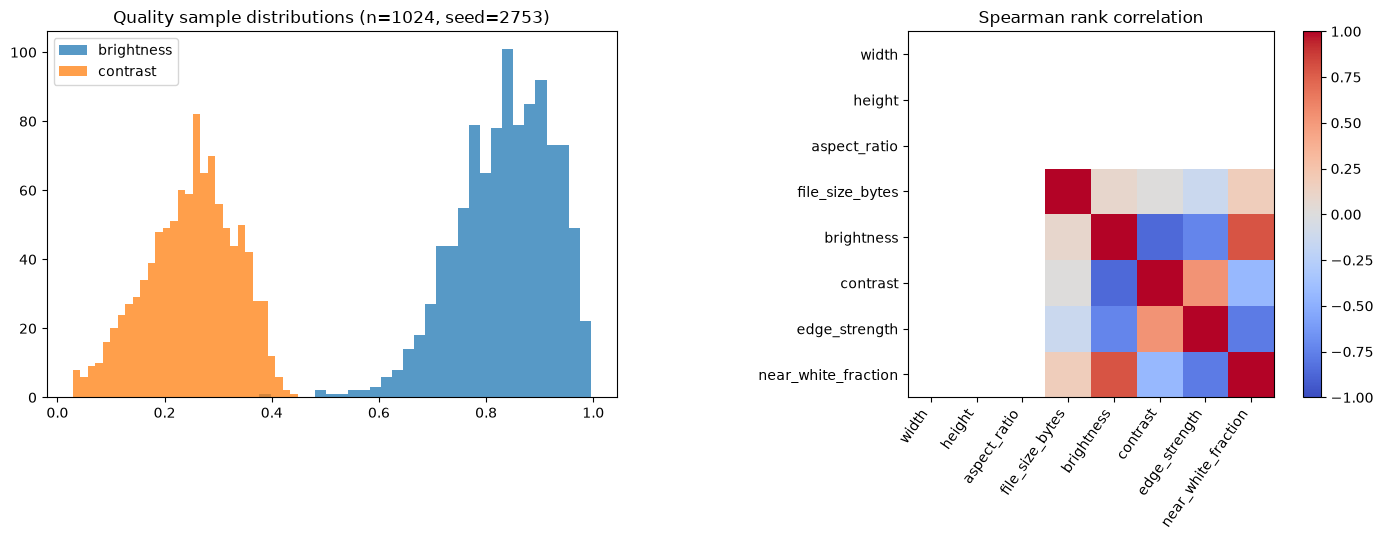

,repository_path,sha256
0,results/figures/data_preparation/image_quality_and_spearman.png,96089f27e955f31f9ff90a524ce1f084e5ad48f27260ba4e692281c28952a6d5


In [20]:
quality_columns = [
    "width", "height", "aspect_ratio", "file_size_bytes",
    "brightness", "contrast", "edge_strength", "near_white_fraction",
]
spearman = quality_sample[quality_columns].corr(method="spearman")
spearman_long = (
    spearman.rename_axis("feature_1").reset_index().melt(
        id_vars="feature_1", var_name="feature_2", value_name="spearman_rho"
    )
)
display(spearman.round(3))
write_table(spearman_long, "image_quality_spearman.csv")

figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].hist(quality_sample["brightness"], bins=30, alpha=0.75, label="brightness")
axes[0].hist(quality_sample["contrast"], bins=30, alpha=0.75, label="contrast")
axes[0].set_title(f"Quality sample distributions (n={QUALITY_SAMPLE_SIZE}, seed={RANDOM_SEED})")
axes[0].legend()
matrix = axes[1].imshow(spearman.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_xticks(range(len(quality_columns)), quality_columns, rotation=55, ha="right")
axes[1].set_yticks(range(len(quality_columns)), quality_columns)
axes[1].set_title("Spearman rank correlation")
figure.colorbar(matrix, ax=axes[1], fraction=0.046)
figure.tight_layout()
figure_record = save_figure(figure, "image_quality_and_spearman.png")
plt.show()
display(pd.DataFrame([figure_record]))


**Finding.** Spearman correlation describes monotonic relationships in a deterministic
sample of development images (`n=1024`, seed `2753`). It does not establish cause and
does not define any task transform or fitted statistic.


## 13. Labelled development contact sheet

**Purpose.** Make metadata-image mismatches visible. A fixed seed selects development
rows only; every image is shown with its ID and all four target tags.


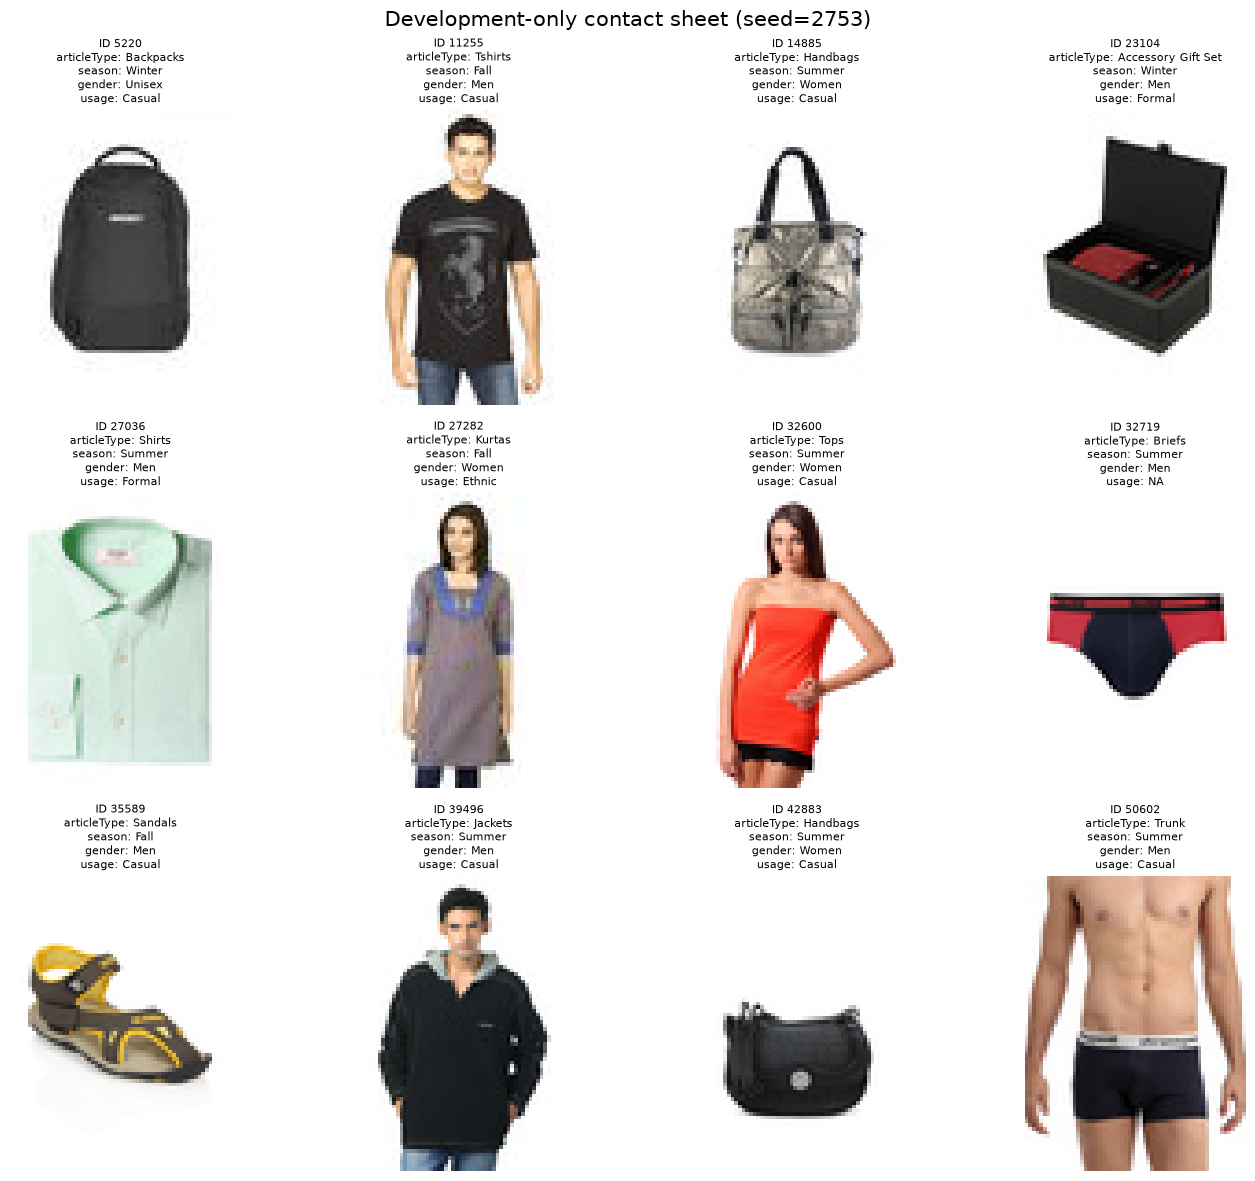

,repository_path,sha256
0,results/figures/data_preparation/development_contact_sheet.png,49cc9810ef442dbc1e1d337f65adf6e50b043bf40b58cc5bc7a1e356bc10762d


Wrote results/evidence/data_preparation/development_contact_sheet_index.csv | rows=12 | sha256=51c1095b102393a3577eed529ed949501672d21b58dcf2514442fa73a2ee989e


'results/evidence/data_preparation/development_contact_sheet_index.csv'

In [21]:
CONTACT_SHEET_SIZE = 12
contact_rows = development.sample(n=CONTACT_SHEET_SIZE, random_state=RANDOM_SEED).sort_values("id")
figure, axes = plt.subplots(3, 4, figsize=(14, 12))
contact_index = []
for axis, (_, row) in zip(axes.ravel(), contact_rows.iterrows()):
    with Image.open(ROOT / str(row["path"])) as source:
        axis.imshow(source.convert("RGB"))
    tags = "\n".join(f"{target}: {row[target] or '<missing>'}" for target in TARGETS)
    axis.set_title(f"ID {int(row['id'])}\n{tags}", fontsize=8)
    axis.axis("off")
    contact_index.append({"id": int(row["id"]), "path": str(row["path"]), **{target: row[target] for target in TARGETS}})
figure.suptitle(f"Development-only contact sheet (seed={RANDOM_SEED})", fontsize=15)
figure.tight_layout()
figure_record = save_figure(figure, "development_contact_sheet.png")
plt.show()
display(pd.DataFrame([figure_record]))
write_table(pd.DataFrame(contact_index), "development_contact_sheet_index.csv")


**Finding.** The contact sheet connects each pixel example to the exact metadata row.
It is a deterministic audit sample, not evidence that all labels are visually
inferable.


## 14. Duplicate, missing-image, and quality-extreme examples

**Purpose.** Show concrete failure modes instead of reporting only aggregate counts.


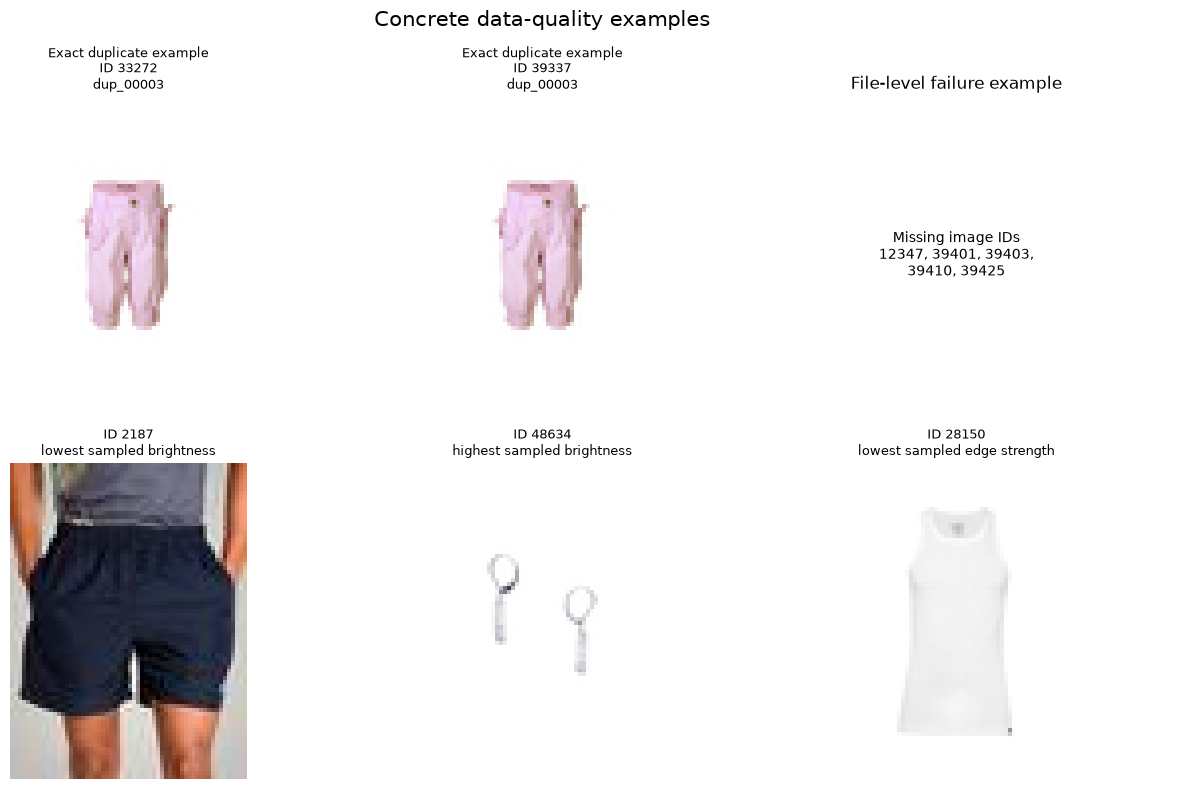

,repository_path,sha256
0,results/figures/data_preparation/data_quality_examples.png,753ac993e31aa0dc01cb14639b1fbca9bb5af0c60a2f75af0f4ba5b7b641f979


Wrote results/evidence/data_preparation/data_quality_example_index.csv | rows=5 | sha256=974d1bae77d88a309a264ddeba77edd8046ecc53d7c7f29eb476dd35ba912f84


'results/evidence/data_preparation/data_quality_example_index.csv'

In [22]:
duplicate_sizes = development.groupby("duplicate_group")["id"].transform("size")
duplicate_examples = development[duplicate_sizes.gt(1)].sort_values(["duplicate_group", "id"]).head(2)
quality_extremes = pd.concat(
    [
        quality_sample.nsmallest(1, "brightness").assign(example_reason="lowest sampled brightness"),
        quality_sample.nlargest(1, "brightness").assign(example_reason="highest sampled brightness"),
        quality_sample.nsmallest(1, "edge_strength").assign(example_reason="lowest sampled edge strength"),
    ],
    ignore_index=True,
).drop_duplicates("id")

figure, axes = plt.subplots(2, 3, figsize=(13, 8))
example_index = []
for axis, (_, row) in zip(axes[0, :2], duplicate_examples.iterrows()):
    with Image.open(ROOT / str(row["path"])) as source:
        axis.imshow(source.convert("RGB"))
    axis.set_title(f"Exact duplicate example\nID {int(row['id'])}\n{row['duplicate_group']}", fontsize=9)
    axis.axis("off")
    example_index.append({"id": int(row["id"]), "reason": "exact duplicate", "path": str(row["path"])})
axes[0, 2].text(0.5, 0.5, "Missing image IDs\n12347, 39401, 39403,\n39410, 39425", ha="center", va="center")
axes[0, 2].set_title("File-level failure example")
axes[0, 2].axis("off")
for axis, row in zip(axes[1], quality_extremes.itertuples(index=False)):
    with Image.open(ROOT / row.path) as source:
        axis.imshow(source.convert("RGB"))
    axis.set_title(f"ID {row.id}\n{row.example_reason}", fontsize=9)
    axis.axis("off")
    example_index.append({"id": int(row.id), "reason": row.example_reason, "path": row.path})
figure.suptitle("Concrete data-quality examples", fontsize=15)
figure.tight_layout()
figure_record = save_figure(figure, "data_quality_examples.png")
plt.show()
display(pd.DataFrame([figure_record]))
write_table(pd.DataFrame(example_index), "data_quality_example_index.csv")


**Finding.** Duplicate pixels can overstate validation performance if separated.
Missing files must be excluded before splitting. Visual extremes should be revisited
during each task's error analysis.


## 15. Transform-risk illustration

**Purpose.** Demonstrate how stretch, centre crop, and padding alter the same source.
This is a risk illustration only; no final size or transform is selected here.


In [23]:
def transform_risk_views(source: Image.Image, canvas: tuple[int, int] = (160, 160)) -> dict[str, Image.Image]:
    rgb = source.convert("RGB")
    return {
        "source": rgb,
        "stretch": rgb.resize(canvas, Image.Resampling.BILINEAR),
        "centre_crop": ImageOps.fit(rgb, canvas, method=Image.Resampling.BILINEAR, centering=(0.5, 0.5)),
        "pad": ImageOps.pad(rgb, canvas, method=Image.Resampling.BILINEAR, color=(255, 255, 255), centering=(0.5, 0.5)),
    }

"definition-only: visual transform comparison; no task policy is chosen"


'definition-only: visual transform comparison; no task policy is chosen'

**Definition only.** These views exist solely to expose different distortion risks.
The next cell applies them to one development example.


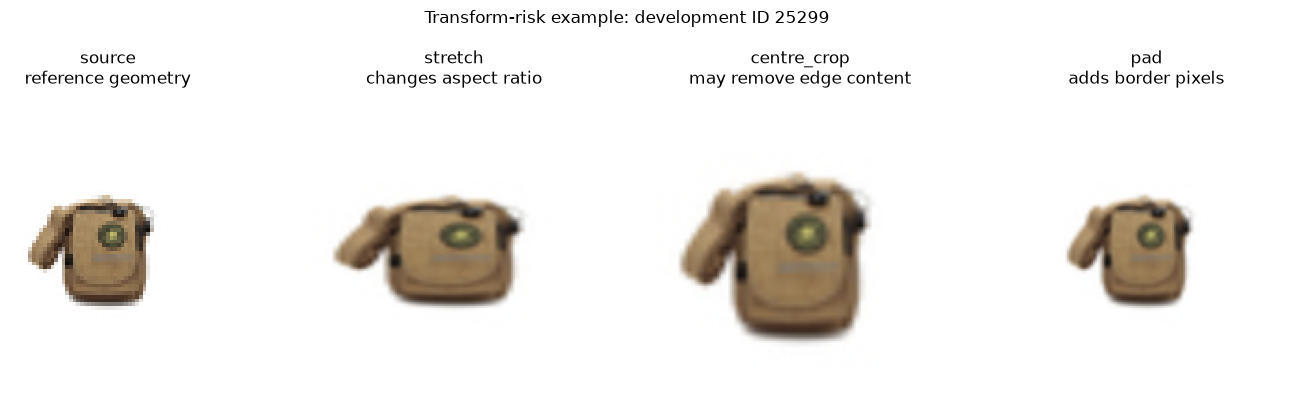

,repository_path,sha256
0,results/figures/data_preparation/transform_risk.png,1b3fd1ed09b5cd1a7853ab611cd30bd79710d29debf19e59531dc6be7e231cea


Wrote results/evidence/data_preparation/transform_risk_examples.csv | rows=4 | sha256=3acb785e0420e2e614537da09b7b58f3d7428e73ee3ba2d2971a0403965beeb7


'results/evidence/data_preparation/transform_risk_examples.csv'

In [24]:
transform_row = development.sort_values(["aspect_ratio", "id"]).iloc[0]
with Image.open(ROOT / str(transform_row["path"])) as source:
    views = transform_risk_views(source)
figure, axes = plt.subplots(1, 4, figsize=(14, 4))
risk_notes = {
    "source": "reference geometry",
    "stretch": "changes aspect ratio",
    "centre_crop": "may remove edge content",
    "pad": "adds border pixels",
}
for axis, (name, view) in zip(axes, views.items()):
    axis.imshow(view)
    axis.set_title(f"{name}\n{risk_notes[name]}")
    axis.axis("off")
figure.suptitle(f"Transform-risk example: development ID {int(transform_row['id'])}")
figure.tight_layout()
figure_record = save_figure(figure, "transform_risk.png")
plt.show()
display(pd.DataFrame([figure_record]))
transform_risk = pd.DataFrame(
    [{"id": int(transform_row["id"]), "method": name, "risk": risk_notes[name]} for name in views]
)
write_table(transform_risk, "transform_risk_examples.csv")


**Finding.** Every strategy changes the pixels in a different way. The correct choice
depends on the task and must be compared inside that task's training-fold workflow.


## 16. Artifact registry and lineage

**Purpose.** Record what produced each handoff, who may use it, and its current hash.
`development_image_profile.json` remains description-only.


In [25]:
lineage = pd.DataFrame(
    [
        ("teacher CSV header + ordered IDs", "audit_raw_data", "audit/csv_summary.json", "structure and reconciliation"),
        ("teacher image raw bytes", "audit_raw_data", "audit/image_audit.csv.gz", "integrity and exact hashes"),
        ("image hashes + perceptual candidates + names", "build_product_families", "audit/product_family_groups.csv.gz", "group boundary"),
        ("fixed IDs + family groups", "make_splits", "splits.csv", "all task notebooks"),
        ("development labels only", "write_label_maps_from_splits", "label_maps.json", "task-local encoders"),
        ("development image facts", "write_development_image_profile", "development_image_profile.json", "description only"),
    ],
    columns=["input_scope", "producer", "artifact", "consumer_or_limit"],
)
display(lineage)
write_table(lineage, "lineage.csv")

provenance = {
    "schema_version": "1.0.0",
    "shared_source_policy": "teacher_only",
    "development_eda_only": True,
    "protected_target_values_used": 0,
    "cv_seed": RANDOM_SEED,
    "cv_folds": 5,
    "model_fit_allowed": False,
    "lineage_file": "results/evidence/data_preparation/lineage.csv",
}
provenance_path = EVIDENCE_DIR / "provenance.json"
provenance_path.write_text(json.dumps(provenance, indent=2, sort_keys=True) + "\n", encoding="utf-8")
print(f"Wrote {relative(provenance_path)} | sha256={sha256_file(provenance_path)}")

preparation_summary = {
    "schema_version": "1.0.0",
    "status": "ready",
    "partition_counts": {key: int(value) for key, value in splits["partition"].value_counts().items()},
    "cv_fold_counts": {
        str(int(key)): int(value)
        for key, value in development["cv_fold"].value_counts().sort_index().items()
    },
    "official_prediction_rows": 5829,
    "known_labelled_ids_without_valid_image": [12347, 39401, 39403, 39410, 39425],
    "active_group_crossings": int(
        group_boundary_audit[["active_partition_crossings", "development_fold_crossings"]]
        .to_numpy()
        .sum()
    ),
    "protected_target_values_used": 0,
    "model_training_runs": 0,
}
summary_path = EVIDENCE_DIR / "summary.json"
summary_path.write_text(json.dumps(preparation_summary, indent=2, sort_keys=True) + "\n", encoding="utf-8")
print(f"Wrote {relative(summary_path)} | sha256={sha256_file(summary_path)}")


,input_scope,producer,artifact,consumer_or_limit
0,teacher CSV header + ordered IDs,audit_raw_data,audit/csv_summary.json,structure and reconciliation
1,teacher image raw bytes,audit_raw_data,audit/image_audit.csv.gz,integrity and exact hashes
2,image hashes + perceptual candidates + names,build_product_families,audit/product_family_groups.csv.gz,group boundary
3,fixed IDs + family groups,make_splits,splits.csv,all task notebooks
4,development labels only,write_label_maps_from_splits,label_maps.json,task-local encoders
5,development image facts,write_development_image_profile,development_image_profile.json,description only


Wrote results/evidence/data_preparation/lineage.csv | rows=6 | sha256=99f062febd51ab5f94b76d7ef88f4e1e62a6060b62a195553174f1c61ec4afc2
Wrote results/evidence/data_preparation/provenance.json | sha256=d38182de30eb80e7ab0615cc2b151b1a4e07eba95834d3ab4b7b401c224a0370
Wrote results/evidence/data_preparation/summary.json | sha256=4f1c7a4cbf12729cdc3b0d42a4eef9e51448cc4e80d03020185292a925c367da


**Finding.** Lineage names the producer and permitted use of each core handoff. The
JSON summaries contain only development/public structure and zero protected targets.


In [26]:
expected_evidence_files = [
    "raw_inventory.csv",
    "preparation_stage_order.csv",
    "raw_hashing_summary.csv",
    "image_reconciliation.csv",
    "duplicate_family_summary.csv",
    "group_boundary_audit.csv",
    "perceptual_scope_audit.csv",
    "partition_summary.csv",
    "cv_fold_balance.csv",
    "target_summary.csv",
    "imbalance_handoff.csv",
    "joint_target_nmi.csv",
    "development_image_quality_sample.csv",
    "image_quality_spearman.csv",
    "development_contact_sheet_index.csv",
    "data_quality_example_index.csv",
    "transform_risk_examples.csv",
    "lineage.csv",
    "provenance.json",
    "summary.json",
]
expected_figure_files = [
    "target_distributions.png",
    "joint_target_nmi.png",
    "image_quality_and_spearman.png",
    "development_contact_sheet.png",
    "data_quality_examples.png",
    "transform_risk.png",
]
main_artifacts = [
    "data/processed/splits.csv",
    "data/processed/split_summary.json",
    "data/processed/cv_fold_summary.json",
    "data/processed/prediction_manifest.csv",
    "data/processed/taxonomy.json",
    "data/processed/label_maps.json",
    "data/processed/development_class_summary.csv",
    "data/processed/development_image_profile.json",
    "data/processed/preparation_cache.json",
    "data/processed/audit/csv_summary.json",
    "data/processed/audit/image_audit.csv.gz",
    "data/processed/audit/exact_duplicate_groups.csv",
    "data/processed/audit/near_duplicate_candidates.csv.gz",
    "data/processed/audit/product_family_groups.csv.gz",
    *[f"results/evidence/data_preparation/{name}" for name in expected_evidence_files],
    *[f"results/figures/data_preparation/{name}" for name in expected_figure_files],
]
missing_artifacts = sorted(
    repository_path
    for repository_path in set(main_artifacts)
    if not (ROOT / repository_path).is_file()
)
assert not missing_artifacts, f"Required artifacts are missing: {missing_artifacts}"
registry_rows = []
for repository_path in sorted(set(main_artifacts)):
    path = ROOT / repository_path
    row_count = ""
    if path.suffix == ".csv" or path.name.endswith(".csv.gz"):
        row_count = len(pd.read_csv(path, keep_default_na=False))
    registry_rows.append(
        {
            "repository_path": repository_path,
            "bytes": path.stat().st_size,
            "rows_if_tabular": row_count,
            "sha256": sha256_file(path),
        }
    )
artifact_registry = pd.DataFrame(registry_rows)
display(artifact_registry)
write_table(artifact_registry, "artifact_registry.csv")


,repository_path,bytes,rows_if_tabular,sha256
0,data/processed/audit/csv_summary.json,2685,,60d918b7812964b0b46fedc03f53186cbccb382427b37bdc0abedfca168fab49
1,data/processed/audit/exact_duplicate_groups.csv,71111,652,f36d1b9d788d9215cc258748e35c7a2826c4349bc42518fc83e402eafa0d85ea
2,data/processed/audit/image_audit.csv.gz,2531636,44442,e1255de28b73e5c71ca695db15071ee8cb8673c29d0a7c9782a1a0cce6ab8bc6
3,data/processed/audit/near_duplicate_candidates.csv.gz,4917989,113593,de0dcf3f0172854a116bf77b03ea4a38ce9ecda15310a7d4b15e81929933027c
4,data/processed/audit/product_family_groups.csv.gz,854304,38612,856cd4b99c29dddf997219378ac37a7d87ecfa7d987bda8fba696800daf617eb
5,data/processed/cv_fold_summary.json,5163,,eb9fba0b4bb9c401115dfb79e4143412f271a4aeeb52b95d87a8fca792b6b58c
6,data/processed/development_class_summary.csv,16628,142,1be4769870d0650ea321af8b97f619dabfa04c46ce8b1fc825ed9e13a18312f8
7,data/processed/development_image_profile.json,661,,418661e53500d717a2c1dcd99ff4bccfe3a3284c21b58fb56fb55df87674cb89
8,data/processed/label_maps.json,11447,,e67a8a4d2eaae9403ce357fbcae40ed8ff55b6bd8aba6a81d74003d284883012
9,data/processed/prediction_manifest.csv,843406,5829,8d1fdd27721fc8604203b99308ecda9773b1f7c89b8cf6b2a33c82587b14954b


Wrote results/evidence/data_preparation/artifact_registry.csv | rows=40 | sha256=c23d95af37cb99e89fda055807f1dcfe0823a839dddf68df56e783f0ae17785b


'results/evidence/data_preparation/artifact_registry.csv'

**Finding.** Every main processed file, evidence table, and displayed figure is
traceable by repository path and SHA-256. No machine-specific path is stored.


## 17. Teammate handoff

**Purpose.** Show the only supported way to obtain train/validation rows. A task must
provide an explicit transform and refit every learned preprocessing value on that
round's training folds.

```python
splits = load_splits()
training, validation = get_cv_split(splits, validation_fold=OWNER_CHOICE)
dataset = FashionDataset(training, transform=TASK_SPECIFIC_TRANSFORM)
```

Before experiments, the owner records either one fixed validation fold or all five
folds. Mean/std, class weights, samplers, and feature selection—if used—are fitted on
`training`, never on all development. The internal holdout stays sealed.


In [27]:
handoff_rows = []
for fold, training, validation in iter_cv_folds(splits):
    handoff_rows.append(
        {
            "owner_choice": f"validation fold {fold}",
            "training_rows": len(training),
            "validation_rows": len(validation),
            "fit_preprocessing_on": "training rows only",
            "holdout_access": "sealed",
        }
    )
handoff = pd.DataFrame(handoff_rows)
display(handoff)


,owner_choice,training_rows,validation_rows,fit_preprocessing_on,holdout_access
0,validation fold 0,26218,6555,training rows only,sealed
1,validation fold 1,26218,6555,training rows only,sealed
2,validation fold 2,26219,6554,training rows only,sealed
3,validation fold 3,26217,6556,training rows only,sealed
4,validation fold 4,26220,6553,training rows only,sealed


**Finding.** The fold API returns copies from the one canonical split. It never calls
a second random splitter and never chooses a task policy on the owner's behalf.


## 18. Completion gate

**Purpose.** Fail loudly if the shared handoff is incomplete or unsafe.


In [28]:
prediction_manifest = pd.read_csv(ROOT / "data/processed/prediction_manifest.csv", keep_default_na=False)
expected_counts = {"development": 32773, "holdout": 5778, "quarantine": 61}
actual_counts = splits["partition"].value_counts().to_dict()
gate_rows = [
    ("partition counts", actual_counts == expected_counts),
    ("partition ID digests", dict(zip(partition_summary["partition"], partition_summary["id_set_sha256"])) == EXPECTED_DIGESTS),
    ("five complete development folds", set(development["cv_fold"].astype(int)) == set(range(5))),
    ("no active group boundary crossing", group_boundary_audit[["active_partition_crossings", "development_fold_crossings"]].to_numpy().sum() == 0),
    ("cross-role visual components quarantined", cross_role_component_not_quarantined == 0),
    ("fold size range within family bound", fold_size_range <= largest_development_family),
    ("protected labels blank", all(splits.loc[protected, target].eq("").all() for target in TARGETS)),
    ("protected masks false", all((~splits.loc[protected, f"has_{target}_label"]).all() for target in TARGETS)),
    ("official prediction rows ready", len(prediction_manifest) == 5829 and prediction_failures == 0),
    ("description profile not fit-ready", image_profile["allowed_for_model_fit"] is False),
    ("cache valid", cache_status["status"] == "validated"),
]
completion_gate = pd.DataFrame(gate_rows, columns=["gate", "passed"])
display(completion_gate)
assert completion_gate["passed"].all(), completion_gate.loc[~completion_gate["passed"]]
print("DATA PREPARATION READY: later tasks may consume the shared contract.")


,gate,passed
0,partition counts,True
1,partition ID digests,True
2,five complete development folds,True
3,no active group boundary crossing,True
4,cross-role visual components quarantined,True
5,fold size range within family bound,True
6,protected labels blank,True
7,protected masks false,True
8,official prediction rows ready,True
9,description profile not fit-ready,True


DATA PREPARATION READY: later tasks may consume the shared contract.


**Completion result.** The teacher files reconcile, protected labels remain sealed,
the fixed membership and five folds pass leakage checks, development-only analysis is
published, and all main handoff artifacts are registered. This notebook has not
trained or selected anything for a task.
